# Lab 1 | Gradient descent
> Author: Serafym Podolyanchuk

In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

## Part 1

In [3]:
# Starting point
x_0 = np.array([-2, 2])

# Constants
ITER_LIMIT = 10_000
STOPPING_CRITERIA = 0.0001 # 10 ^ (-4)
G = [0.1, 0.01, 0.001] # gamma

/tmp/ipykernel_269/3446289849.py:2: RuntimeWarning: overflow encountered in scalar power
  return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2
/tmp/ipykernel_269/3446289849.py:6: RuntimeWarning: overflow encountered in scalar power
  df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)
/tmp/ipykernel_269/3446289849.py:7: RuntimeWarning: overflow encountered in scalar power
  df_dx2 = 200 * (x2 - x1**2)
/tmp/ipykernel_269/3446289849.py:6: RuntimeWarning: overflow encountered in scalar multiply
  df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)


Diverged with gamma=0.1 at iteration 6
X (k) = [nan nan] after 6 iterations which took 0.0008056559999971569 time
Diverged with gamma=0.01 at iteration 6
X (k) = [nan nan] after 6 iterations which took 0.0003501009999951066 time
X (k) = [0.99117313 0.98238866] after 10000 iterations which took 0.5888835829999977 time


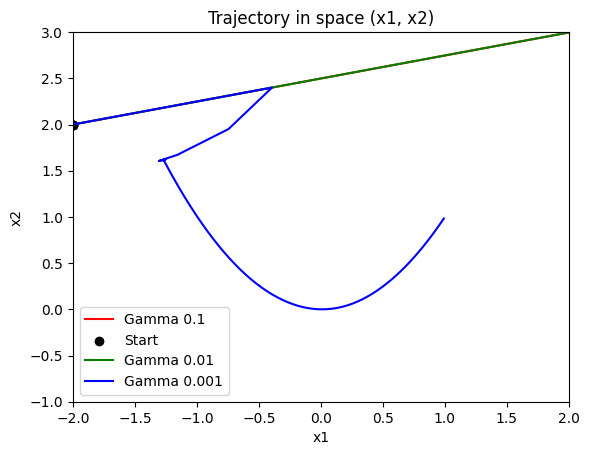

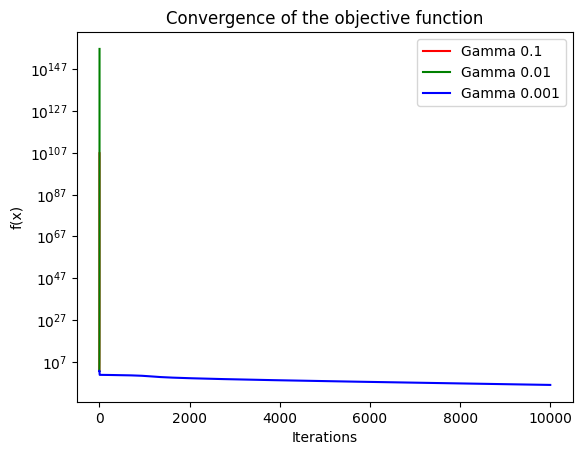

In [4]:
def calculate_objective(x):
    return 100 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

def compute_gradient(x):
    x1, x2 = x[0], x[1]
    df_dx1 = -400 * x1 * (x2 - x1**2) - 2 * (1 - x1)
    df_dx2 = 200 * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])

def gradient_descent(x_0, iter_limit, stopping_criteria, gamma):
  x_k = np.array(x_0, dtype=float)

  history = []
  objective_history = []

  start_time = time.perf_counter()

  iter_count = 0
  while iter_count < iter_limit:
    grad = compute_gradient(x_k)
    history.append(x_k)
    objective_history.append(calculate_objective(x_k))

    if np.linalg.norm(grad) < stopping_criteria:
      break

    x_k = x_k - gamma * grad

    iter_count += 1

    if not np.isfinite(x_k).all():
      print(f"Diverged with gamma={gamma} at iteration {iter_count}")
      return np.array([np.nan, np.nan]), iter_count, time.perf_counter() - start_time, history, objective_history

  duration = time.perf_counter() - start_time

  return x_k, iter_count, duration, history, objective_history

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for g,c in zip(G, ["red", "green","blue"]):
  x_k, iter_count, duration, history, objective_history = gradient_descent(x_0, ITER_LIMIT, STOPPING_CRITERIA, g)
  print(f"X (k) = {x_k} after {iter_count} iterations which took {duration} time")

  history = np.array(history)
  objective_history = np.array(objective_history)

  if np.isfinite(history).all() and len(history) > 0:
      ax1.plot(history[:, 0], history[:, 1], label=f"Gamma {g}", color=c)
      ax1.scatter(history[0,0], history[0,1], color='black', label="Start" if g==G[0] else "")

      ax2.plot(range(len(objective_history)), objective_history, label=f"Gamma {g}", color=c)

ax1.set_title("Trajectory in space (x1, x2)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 3)
ax1.legend()

ax2.set_title("Convergence of the objective function")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("f(x)")
ax2.set_yscale('log')
ax2.legend()

plt.show()

X (k) = [0.99988822 0.999776  ] after 20903 iterations which took 0.2483162499999878 time
X (k) = [0.99988821 0.99977598] after 2125468 iterations which took 28.024681099999995 time
X (k) = [-0.76180113  0.58842339] after 10000000 iterations which took 132.542528122 time


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


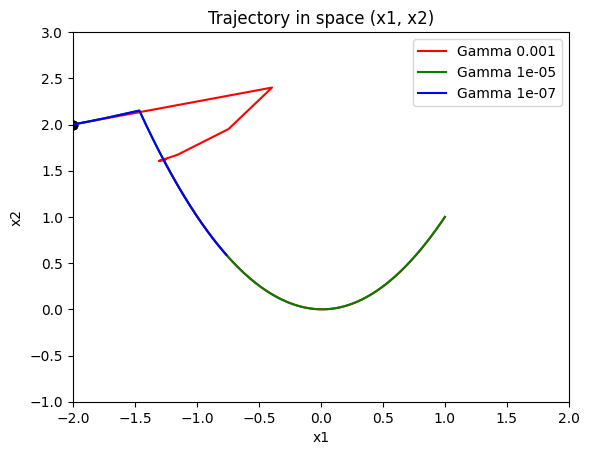

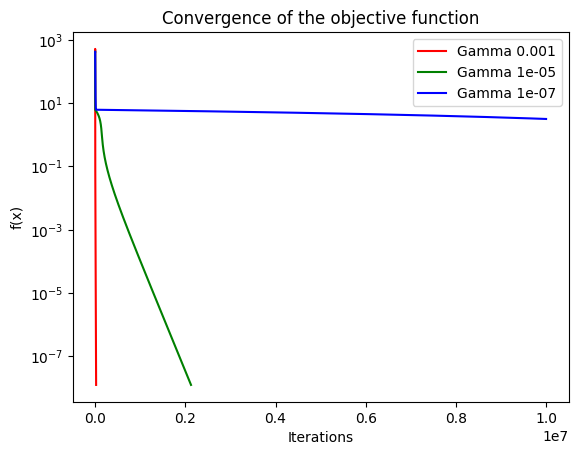

In [5]:
lowest_g = [0.001, 0.00001, 0.0000001]

fig1, ax1 = plt.subplots()
fig2, ax2 = plt.subplots()

for g,c in zip(lowest_g, ["red", "green","blue"]):
  x_k, iter_count, duration, history, objective_history = gradient_descent(x_0, 10_000_000, STOPPING_CRITERIA, g)
  print(f"X (k) = {x_k} after {iter_count} iterations which took {duration} time")

  history = np.array(history)
  objective_history = np.array(objective_history)

  if np.isfinite(history).all() and len(history) > 0:
      ax1.plot(history[:, 0], history[:, 1], label=f"Gamma {g}", color=c)
      ax1.scatter(history[0,0], history[0,1], color='black', label="Start" if g==G[0] else "")

      ax2.plot(range(len(objective_history)), objective_history, label=f"Gamma {g}", color=c)

ax1.set_title("Trajectory in space (x1, x2)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 3)
ax1.legend()

ax2.set_title("Convergence of the objective function")
ax2.set_xlabel("Iterations")
ax2.set_ylabel("f(x)")
ax2.set_yscale('log')
ax2.legend()

plt.show()

## Part 2

In [6]:
m, n = 100, 10
A = np.random.randn(m, n)
b = np.random.randn(m)
x_0 = np.zeros(n)
ITER_LIMIT = 50

In [7]:
def calculate_objective(x, A, b):
    m = len(b)
    error = A @ x - b
    return (1 / (2 * m)) * np.linalg.norm(error)**2

def compute_gradient(x, A, b):
    m = len(b)
    return (1 / m) * A.T @ (A @ x - b)

def gradient_descent(x_0, A, b, iter_limit, gamma):
    x_k = np.array(x_0, dtype=float)
    obj_history = []
    start_time = time.perf_counter()

    for i in range(iter_limit):
        obj_history.append(calculate_objective(x_k, A, b))
        grad = compute_gradient(x_k, A, b)
        x_k = x_k - gamma * grad

    duration = time.perf_counter() - start_time
    return x_k, duration, obj_history

gamma=0.1: Final Obj = 0.454687, Time = 0.002492s
gamma=1/beta: Final Obj = 0.454652, Time = 0.001437s
gamma=1/L: Final Obj = 0.457233, Time = 0.001306s


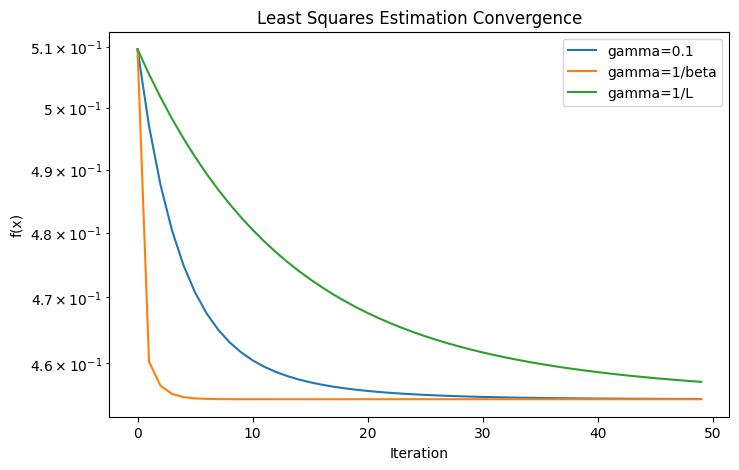

In [8]:
beta = (1/m) * (np.linalg.norm(A, 2)**2)
L = (1/m) * (np.linalg.norm(A.T @ A, 2) * 20 + np.linalg.norm(A.T @ b, 2))

gammas_2 = [0.1, 1/beta, 1/L]
labels_2 = ["gamma=0.1", "gamma=1/beta", "gamma=1/L"]

fig, ax = plt.subplots(figsize=(8, 5))

for g, lbl in zip(gammas_2, labels_2):
    res, dur, hist = gradient_descent(x_0, A, b, ITER_LIMIT, g)
    print(f"{lbl}: Final Obj = {hist[-1]:.6f}, Time = {dur:.6f}s")
    ax.plot(range(len(hist)), hist, label=lbl)

ax.set_title("Least Squares Estimation Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("f(x)")
ax.set_yscale('log')
ax.legend()
plt.show()

## Part 3

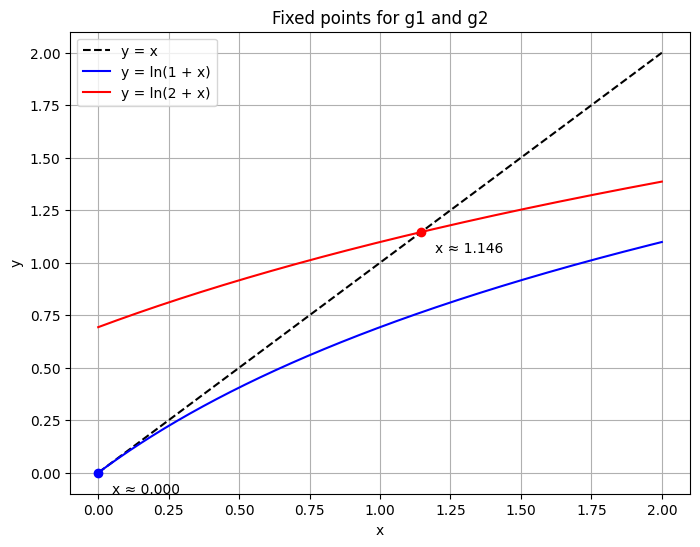

Approximate fixed point for ln(1+x): x ≈ 0.0000
Approximate fixed point for ln(2+x): x ≈ 1.1463


In [9]:
x = np.linspace(0, 2, 500)

y_x = x
y_g1 = np.log(1 + x)
y_g2 = np.log(2 + x)

plt.figure(figsize=(8, 6))
plt.plot(x, y_x, label="y = x", color="black", linestyle="--")
plt.plot(x, y_g1, label="y = ln(1 + x)", color="blue")
plt.plot(x, y_g2, label="y = ln(2 + x)", color="red")

fixed_point_1 = 0.0

idx_2 = np.argmin(np.abs(y_x - y_g2))
fixed_point_2 = x[idx_2]

plt.scatter([fixed_point_1], [np.log(1 + fixed_point_1)], color='blue', zorder=5)
plt.scatter([fixed_point_2], [np.log(2 + fixed_point_2)], color='red', zorder=5)

plt.annotate(f"x ≈ {fixed_point_1:.3f}", (fixed_point_1, np.log(1 + fixed_point_1)), xytext=(10, -15), textcoords='offset points')
plt.annotate(f"x ≈ {fixed_point_2:.3f}", (fixed_point_2, np.log(2 + fixed_point_2)), xytext=(10, -15), textcoords='offset points')

plt.title("Fixed points for g1 and g2")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

print(f"Approximate fixed point for ln(1+x): x ≈ {fixed_point_1:.4f}")
print(f"Approximate fixed point for ln(2+x): x ≈ {fixed_point_2:.4f}")

In [16]:
def g1(x): return 0.5 * (x - np.log(1 + x))**2
def dg1(x): return (x - np.log(1 + x)) * (1 - 1/(1 + x))

def g2(x): return 0.5 * (x - np.log(2 + x))**2
def dg2(x): return (x - np.log(2 + x)) * (1 - 1/(2 + x))

L1 = 0.54
L2 = 0.60
ITER_LIMIT = 100

def gradient_descent(x_0, g_func, dg_func, iter_limit, gamma):
    x_k = float(x_0)
    obj_history = []
    x_values = []
    start_time = time.perf_counter()

    for i in range(iter_limit):
        if i % 10 == 0:
            x_values.append((i, x_k, g_func(x_k)))
        obj_history.append(g_func(x_k))
        x_k = x_k - gamma * dg_func(x_k)

    duration = time.perf_counter() - start_time
    return x_k, duration, obj_history, x_values


Results for g1 (ln(1+x)):
Iter 0: x=2.0000, g(x)=4.0625e-01
Iter 10: x=0.2924, g(x)=6.4443e-04
Iter 20: x=0.1986, g(x)=1.5225e-04
Iter 30: x=0.1583, g(x)=6.4382e-05
Iter 40: x=0.1349, g(x)=3.4866e-05
Iter 50: x=0.1192, g(x)=2.1662e-05
Iter 60: x=0.1078, g(x)=1.4686e-05
Iter 70: x=0.0990, g(x)=1.0578e-05
Iter 80: x=0.0920, g(x)=7.9633e-06
Iter 90: x=0.0863, g(x)=6.2014e-06

Results for g2 (ln(2+x)):
Iter 0: x=2.0000, g(x)=1.8832e-01
Iter 10: x=1.1462, g(x)=3.0769e-15
Iter 20: x=1.1462, g(x)=3.2602e-28
Iter 30: x=1.1462, g(x)=0.0000e+00
Iter 40: x=1.1462, g(x)=0.0000e+00
Iter 50: x=1.1462, g(x)=0.0000e+00
Iter 60: x=1.1462, g(x)=0.0000e+00
Iter 70: x=1.1462, g(x)=0.0000e+00
Iter 80: x=1.1462, g(x)=0.0000e+00
Iter 90: x=1.1462, g(x)=0.0000e+00


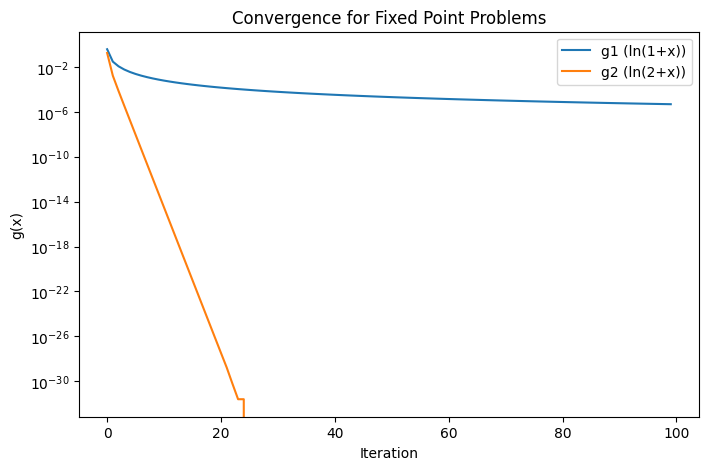

In [17]:
x_k1, dur1, hist1, vals1 = gradient_descent(2.0, g1, dg1, ITER_LIMIT, 1/L1)
print("\nResults for g1 (ln(1+x)):")
for i, x, val in vals1: print(f"Iter {i}: x={x:.4f}, g(x)={val:.4e}")

x_k2, dur2, hist2, vals2 = gradient_descent(2.0, g2, dg2, ITER_LIMIT, 1/L2)
print("\nResults for g2 (ln(2+x)):")
for i, x, val in vals2: print(f"Iter {i}: x={x:.4f}, g(x)={val:.4e}")

plt.figure(figsize=(8, 5))
plt.plot(hist1, label="g1 (ln(1+x))")
plt.plot(hist2, label="g2 (ln(2+x))")
plt.title("Convergence for Fixed Point Problems")
plt.xlabel("Iteration")
plt.ylabel("g(x)")
plt.yscale('log')
plt.legend()
plt.show()